<a href="https://colab.research.google.com/github/shiblidata/computer-vision-pattern-recognition/blob/main/efficient_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATASET_ROOT = "/content/drive/MyDrive/CVPR/AquPlantDS"

In [4]:
import os

DATASET_ROOT = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS"

print("Dataset Root:")
print(DATASET_ROOT)

print("\nContents:")
print(os.listdir(DATASET_ROOT))

Dataset Root:
/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS

Contents:
['.DS_Store', 'Classification', 'Segmentation']


In [5]:
CLASSIFICATION_ROOT = os.path.join(DATASET_ROOT, "Classification")

print("Classification contents:")
print(os.listdir(CLASSIFICATION_ROOT))

Classification contents:
['Test', 'Train']


In [6]:
def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += sum(
            f.lower().endswith(('.jpg', '.jpeg', '.png'))
            for f in files
        )
    return total

for name in os.listdir(CLASSIFICATION_ROOT):
    path = os.path.join(CLASSIFICATION_ROOT, name)
    if os.path.isdir(path):
        print(name, ":", count_images(path))

Test : 406
Train : 1062


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [8]:
FINAL_ROOT = candidates[0]

print("Using:", FINAL_ROOT)
print(os.listdir(FINAL_ROOT))

NameError: name 'candidates' is not defined

In [16]:
import os
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


In [17]:
FINAL_ROOT = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification"
train_dir = os.path.join(FINAL_ROOT, "Train")
val_dir   = os.path.join(FINAL_ROOT, "Validation") # This directory will not be used, validation is split from train_dataset
test_dir  = os.path.join(FINAL_ROOT, "Test")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Train
Validation: /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Validation
Test: /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Test


In [12]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        total += sum(
            f.lower().endswith(IMG_EXTENSIONS)
            for f in files
        )

    return total


train_count = count_images(train_dir)
val_count   = count_images(val_dir)
test_count  = count_images(test_dir)

print("Train images     :", train_count)
print("Validation images:", val_count)
print("Test images      :", test_count)

Train images     : 1062
Validation images: 0
Test images      : 406


In [13]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        total += sum(
            f.lower().endswith(IMG_EXTENSIONS)
            for f in files
        )

    return total


train_count = count_images(train_dir)
val_count   = count_images(val_dir)
test_count  = count_images(test_dir)

print("Train images     :", train_count)
print("Validation images:", val_count)
print("Test images      :", test_count)

Train images     : 1062
Validation images: 0
Test images      : 406


In [15]:
assert train_count == 1062, f"Train count mismatch: {train_count}"
assert val_count == 0, f"Validation count mismatch: {val_count}"
assert test_count == 406, f"Test count mismatch: {test_count}"

print("Dataset counts verified ✅")

Dataset counts verified ✅


In [16]:
IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [18]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

print("\nClasses:")
for i, c in enumerate(train_dataset.classes):
    print(i, "->", c)

Train: 1062
Test: 406

Classes:
0 -> Class_10_lippia_alba
1 -> Class_11_marsilea_minuta
2 -> Class_12_duck_weeds
3 -> Class_13_topapana
4 -> Class_14_kachuripana
5 -> Class_1_water_iris
6 -> Class_2_pistia_stratiotes
7 -> Class_3_lily_leaf
8 -> Class_4_lotus-leaf
9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily


In [20]:
assert train_dataset.class_to_idx == test_dataset.class_to_idx

assert len(train_dataset.classes) == 14
print("\nClass mapping verified ✅")


Class mapping verified ✅


In [22]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Paths
train_dir = os.path.join(FINAL_ROOT, "Train")
val_dir   = os.path.join(FINAL_ROOT, "Validation")
test_dir  = os.path.join(FINAL_ROOT, "Test")

print("Train path:", train_dir)
print("Validation path:", val_dir)
print("Test path:", test_dir)

# Preprocessing
IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Create datasets
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=eval_transform
)

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nClasses:", len(train_dataset.classes))
print(train_dataset.classes)

# Verify mapping
assert train_dataset.class_to_idx == val_dataset.class_to_idx
assert train_dataset.class_to_idx == test_dataset.class_to_idx

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Verify batch
images, labels = next(iter(train_loader))

print("\nBatch verification:")
print("Image batch:", images.shape)
print("Label batch:", labels.shape)

print("\nDATASET + DATALOADER READY ✅")

Train path: /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Train
Validation path: /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Validation
Test path: /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Test


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Validation'

In [23]:
FINAL_ROOT = "/content/drive/MyDrive/CVPR/AquPlantDS_FINAL"

train_dir = FINAL_ROOT + "/Train"
val_dir   = FINAL_ROOT + "/Validation"
test_dir  = FINAL_ROOT + "/Test"

In [34]:
import os

print(os.listdir(FINAL_ROOT))

['Test', 'Train']


In [25]:
import os

CVPR_ROOT = "/content/drive/MyDrive/CVPR"

for root, dirs, files in os.walk(CVPR_ROOT):
    if {"Train", "Validation", "Test"}.issubset(set(dirs)):
        print("FOUND:", root)

In [26]:
FINAL_ROOT = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/SomeFolder"

In [33]:
print(os.listdir(FINAL_ROOT))

['Test', 'Train']


In [28]:
BASE = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a"

In [29]:
import os

BASE = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a"

found = []

for root, dirs, files in os.walk(BASE):
    if {"Train", "Validation", "Test"}.issubset(set(dirs)):
        found.append(root)

if found:
    print("FOUND FINAL DATASET:")
    for i, path in enumerate(found):
        print(i, "->", path)
else:
    print("No Train/Validation/Test dataset found.")

No Train/Validation/Test dataset found.


In [32]:
FINAL_ROOT = CLASSIFICATION_ROOT

print("FINAL_ROOT =", FINAL_ROOT)
print(os.listdir(FINAL_ROOT))

FINAL_ROOT = /content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification
['Test', 'Train']


In [31]:
BASE = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a"

for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, "").count(os.sep)

    if depth <= 2:
        print("    " * depth + os.path.basename(root) + "/")

UAV-Based Aquatic Plant Dataset for Segmentation a/
    AquPlantDS/
        Classification/
        Segmentation/


In [35]:
BASE = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a"

for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, "").count(os.sep)

    if depth <= 2:
        print("    " * depth + os.path.basename(root) + "/")

UAV-Based Aquatic Plant Dataset for Segmentation a/
    AquPlantDS/
        Classification/
        Segmentation/


In [12]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

TRAIN_DIR = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Train"

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

full_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=transform
)

print("Total training images:", len(full_train_dataset))
print("Classes:", len(full_train_dataset.classes))

Total training images: 1062
Classes: 14


In [13]:
total_size = len(full_train_dataset)

val_size = int(0.15 * total_size)
train_size = total_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 903
Validation: 159


In [14]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train loader:", len(train_loader))
print("Validation loader:", len(val_loader))

images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Train loader: 29
Validation loader: 5
Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])


In [18]:
NUM_CLASSES = 14

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

# Freeze convolutional backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classification layer
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=14, bias=True)
)


In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss      :", criterion)
print("Optimizer :", optimizer.__class__.__name__)
print("Scheduler :", scheduler.__class__.__name__)

Loss      : CrossEntropyLoss()
Optimizer : AdamW
Scheduler : ReduceLROnPlateau


In [19]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0.0

    all_targets = []
    all_preds = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        all_targets.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_acc = accuracy_score(
        all_targets,
        all_preds
    )

    epoch_f1 = f1_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_acc, epoch_f1

In [20]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)

            all_targets.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1,
        "targets": np.array(all_targets),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

In [15]:
EPOCHS = 30
PATIENCE = 7

history = []

best_f1 = -1
best_epoch = 0
best_state = None

epochs_without_improvement = 0

start_time = time.time()


for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_result = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_result["macro_f1"])

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,

        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "val_macro_f1": val_result["macro_f1"],

        "lr": current_lr
    })


    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Train F1: {train_f1*100:.2f}% || "
        f"Val Loss: {val_result['loss']:.4f} | "
        f"Val Acc: {val_result['accuracy']*100:.2f}% | "
        f"Val F1: {val_result['macro_f1']*100:.2f}% | "
        f"LR: {current_lr:.2e}"
    )


    # Save by validation Macro-F1
    if val_result["macro_f1"] > best_f1:

        best_f1 = val_result["macro_f1"]

        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


training_time = time.time() - start_time

print(
    f"\nTraining finished in "
    f"{training_time/60:.2f} minutes"
)

Epoch 01/30 | Train Loss: 2.1055 | Train Acc: 43.30% | Train F1: 43.94% || Val Loss: 1.5179 | Val Acc: 79.25% | Val F1: 79.82% | LR: 1.00e-03
Epoch 02/30 | Train Loss: 1.1461 | Train Acc: 87.38% | Train F1: 87.40% || Val Loss: 0.9713 | Val Acc: 87.42% | Val F1: 87.09% | LR: 1.00e-03
Epoch 03/30 | Train Loss: 0.7385 | Train Acc: 92.91% | Train F1: 92.89% || Val Loss: 0.7408 | Val Acc: 89.31% | Val F1: 88.69% | LR: 1.00e-03
Epoch 04/30 | Train Loss: 0.5672 | Train Acc: 94.24% | Train F1: 94.26% || Val Loss: 0.6119 | Val Acc: 88.68% | Val F1: 88.32% | LR: 1.00e-03
Epoch 05/30 | Train Loss: 0.4343 | Train Acc: 95.24% | Train F1: 95.30% || Val Loss: 0.5310 | Val Acc: 90.57% | Val F1: 90.42% | LR: 1.00e-03
Epoch 06/30 | Train Loss: 0.3716 | Train Acc: 95.24% | Train F1: 95.19% || Val Loss: 0.4793 | Val Acc: 88.68% | Val F1: 88.78% | LR: 1.00e-03
Epoch 07/30 | Train Loss: 0.3145 | Train Acc: 96.23% | Train F1: 96.22% || Val Loss: 0.4451 | Val Acc: 91.82% | Val F1: 91.55% | LR: 1.00e-03
Epoch 

In [27]:
model.load_state_dict(best_state)

print("Best checkpoint restored.")
print("Best epoch:", best_epoch)

Best checkpoint restored.
Best epoch: 9


In [28]:
best_val = evaluate(
    model,
    val_loader,
    criterion
)

print("=" * 60)
print("EFFICIENTNET-B0 FROZEN TRANSFER LEARNING RESULT")
print("=" * 60)

print(f"Best Epoch          : {best_epoch}")

print(
    f"Validation Accuracy : "
    f"{best_val['accuracy']*100:.2f}%"
)

print(
    f"Validation Precision: "
    f"{best_val['precision']*100:.2f}%"
)

print(
    f"Validation Recall   : "
    f"{best_val['recall']*100:.2f}%"
)

print(
    f"Validation Macro-F1 : "
    f"{best_val['macro_f1']*100:.2f}%"
)

print(
    f"Validation Loss     : "
    f"{best_val['loss']:.4f}"
)

print(
    f"Training Time       : "
    f"{training_time/60:.2f} minutes"
)

EFFICIENTNET-B0 FROZEN TRANSFER LEARNING RESULT
Best Epoch          : 9
Validation Accuracy : 94.34%
Validation Precision: 94.59%
Validation Recall   : 94.18%
Validation Macro-F1 : 94.17%
Validation Loss     : 0.3808
Training Time       : 13.75 minutes


In [30]:
SAVE_DIR = os.path.join(
    "/content/drive/MyDrive/CVPR",
    "EfficientNet_B0_Results"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_frozen_best.pth"
)

# Accessing class_to_idx from the original dataset since 'train_dataset' is a Subset
torch.save({
    "model_state_dict": model.state_dict(),
    "best_epoch": best_epoch,
    "class_to_idx": full_train_dataset.class_to_idx,
    "val_macro_f1": best_val["macro_f1"],
    "val_accuracy": best_val["accuracy"]
}, MODEL_PATH)

print("Saved:", MODEL_PATH)

Saved: /content/drive/MyDrive/CVPR/EfficientNet_B0_Results/efficientnet_b0_frozen_best.pth


In [25]:
history_df = pd.DataFrame(history)

history_path = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_frozen_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

history_df.tail()

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_precision,val_recall,val_macro_f1,lr
11,12,0.171950,0.986711,0.986461,0.332561,0.937107,0.940506,0.933838,0.934673,0.00050
12,13,0.179575,0.982281,0.982461,0.318703,0.937107,0.941102,0.935281,0.935837,0.00050
13,14,0.152540,0.985604,0.985317,0.320646,0.930818,0.933990,0.929329,0.929440,0.00050
14,15,0.155766,0.982281,0.982326,0.305731,0.930818,0.934015,0.927345,0.928643,0.00025
15,16,0.145776,0.983389,0.983207,0.300436,0.943396,0.944675,0.941775,0.941489,0.00025


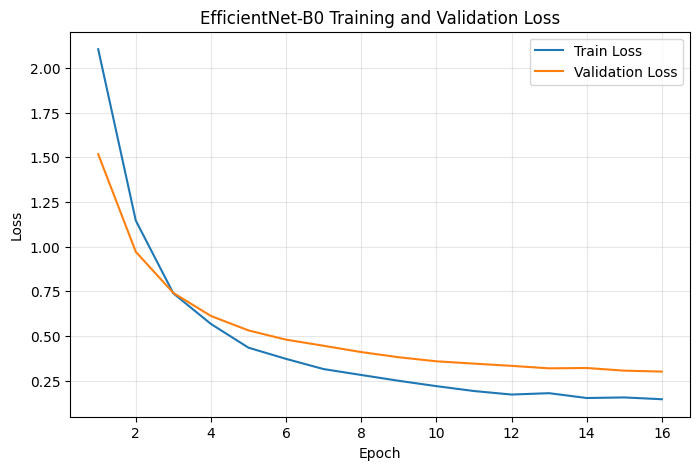

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import os

SAVE_DIR = os.path.join(
    "/content/drive/MyDrive/CVPR",
    "EfficientNet_B0_Results"
)
history_path = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_frozen_history.csv"
)

try:
    history_df = pd.read_csv(history_path)
except FileNotFoundError:
    print(f"Error: History file not found at {history_path}. Please ensure the training and saving steps (cells WdndEkdshr7w and MjSNZqHdxWcp) have been executed successfully.")
    # Fallback: Attempt to create history_df from the 'history' list if it exists
    if 'history' in locals() and isinstance(history, list) and len(history) > 0:
        history_df = pd.DataFrame(history)
        print("Recreated history_df from 'history' list.")
    else:
        print("The 'history' list is also not available or empty. Cannot plot training history.")
        # Create an empty DataFrame to prevent further errors if plotting is attempted
        history_df = pd.DataFrame({'epoch': [], 'train_loss': [], 'val_loss': []})
        print("Created empty DataFrame for plotting.")

# Proceed with plotting only if history_df has data
if not history_df.empty:
    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("EfficientNet-B0 Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
else:
    print("No data available to plot training history.")

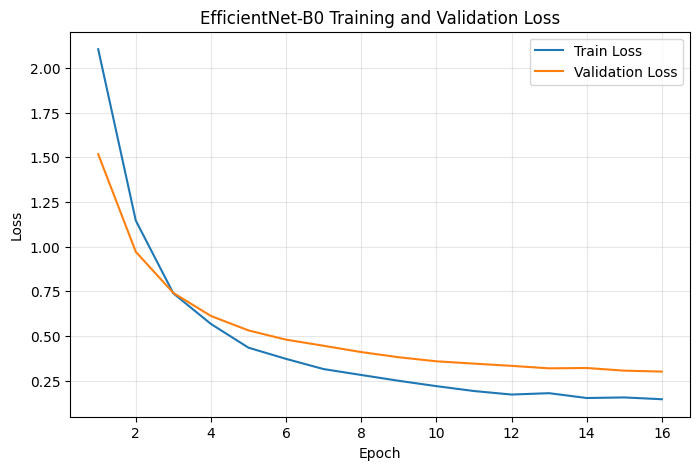

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

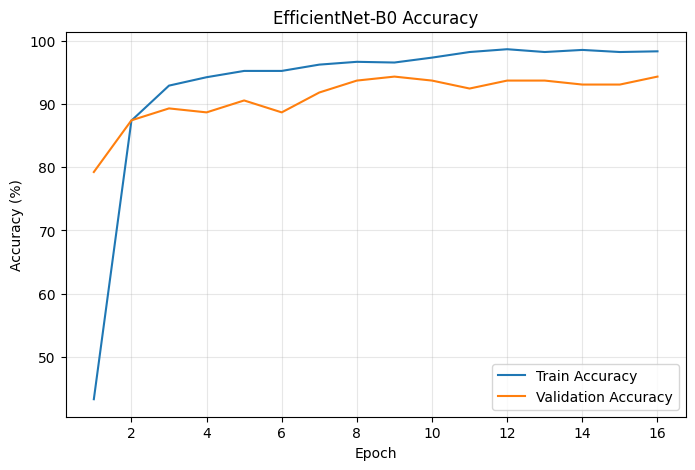

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"] * 100,
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"] * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [34]:
print(
    classification_report(
        best_val["targets"],
        best_val["preds"],
        target_names=full_train_dataset.classes,
        digits=4,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

         Class_10_lippia_alba     0.9091    1.0000    0.9524        10
     Class_11_marsilea_minuta     1.0000    0.8333    0.9091        12
          Class_12_duck_weeds     0.7778    0.8750    0.8235         8
            Class_13_topapana     1.0000    1.0000    1.0000         9
         Class_14_kachuripana     1.0000    0.9333    0.9655        15
           Class_1_water_iris     0.8571    1.0000    0.9231        12
    Class_2_pistia_stratiotes     1.0000    1.0000    1.0000        10
            Class_3_lily_leaf     0.9091    0.9091    0.9091        11
           Class_4_lotus-leaf     0.9333    0.9333    0.9333        15
           Class_5_water_popy     1.0000    0.9091    0.9524        11
             Class_6_salvania     0.9231    1.0000    0.9600        12
Class_7_chinese_water_spinach     1.0000    0.8750    0.9333         8
       Class_8_water_plantain     1.0000    0.9167    0.9565        12
   Cl

In [35]:
import os
import torch

SAVE_DIR = "/content/drive/MyDrive/CVPR/EfficientNet_B0_Results"

FROZEN_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_frozen_best.pth"
)

checkpoint = torch.load(
    FROZEN_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Frozen checkpoint loaded ✅")
print("Frozen best epoch:", checkpoint["best_epoch"])
print(
    "Frozen validation Macro-F1:",
    f'{checkpoint["val_macro_f1"]*100:.2f}%'
)

Frozen checkpoint loaded ✅
Frozen best epoch: 9
Frozen validation Macro-F1: 94.17%


In [36]:
frozen_params = 0
trainable_params = 0

for p in model.parameters():
    if p.requires_grad:
        trainable_params += p.numel()
    else:
        frozen_params += p.numel()

print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters   : {frozen_params:,}")

Trainable parameters: 17,934
Frozen parameters   : 4,007,548


In [37]:
for param in model.features.parameters():
    param.requires_grad = False

In [38]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

# Classifier অবশ্যই trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("Last two EfficientNet feature stages unfrozen ✅")

Last two EfficientNet feature stages unfrozen ✅


In [39]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

features.7.0.block.0.0.weight
features.7.0.block.0.1.weight
features.7.0.block.0.1.bias
features.7.0.block.1.0.weight
features.7.0.block.1.1.weight
features.7.0.block.1.1.bias
features.7.0.block.2.fc1.weight
features.7.0.block.2.fc1.bias
features.7.0.block.2.fc2.weight
features.7.0.block.2.fc2.bias
features.7.0.block.3.0.weight
features.7.0.block.3.1.weight
features.7.0.block.3.1.bias
features.8.0.weight
features.8.1.weight
features.8.1.bias
classifier.1.weight
classifier.1.bias


In [40]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)


Total parameters    : 4,025,482
Trainable parameters: 1,147,326
Trainable percentage: 28.50%


In [41]:
import torch.nn as nn

criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.AdamW(
    [
        {
            "params": model.features[-2:].parameters(),
            "lr": 1e-5
        },
        {
            "params": model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=2
)

print("Fine-tuning optimizer ready ✅")

Fine-tuning optimizer ready ✅


In [42]:
print("Device:", device)

print("\nOptimizer learning rates:")
for i, group in enumerate(optimizer_ft.param_groups):
    print(f"Group {i}: {group['lr']}")

trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"\nTrainable parameters: {trainable_params:,}")

print("\nReady for 50-epoch fine-tuning ✅")

Device: cuda

Optimizer learning rates:
Group 0: 1e-05
Group 1: 0.0001

Trainable parameters: 1,147,326

Ready for 50-epoch fine-tuning ✅


In [ ]:
import os
import copy
import time
import torch
import pandas as pd

FT_EPOCHS = 50

ft_history = []

best_ft_f1 = -1.0
best_ft_epoch = 0
best_ft_state = None

SAVE_DIR = "/content/drive/MyDrive/CVPR/EfficientNet_B0_Results"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_best.pth"
)

LAST_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_last.pth"
)

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_50epochs_history.csv"
)

start_time_ft = time.time()


for epoch in range(1, FT_EPOCHS + 1):

    # -------------------------
    # TRAIN
    # -------------------------
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer_ft,
        criterion_ft
    )

    # -------------------------
    # VALIDATION
    # -------------------------
    val_result = evaluate(
        model,
        val_loader,
        criterion_ft
    )

    # LR scheduler
    scheduler_ft.step(
        val_result["macro_f1"]
    )

    backbone_lr = optimizer_ft.param_groups[0]["lr"]
    classifier_lr = optimizer_ft.param_groups[1]["lr"]

    # -------------------------
    # SAVE HISTORY
    # -------------------------
    ft_history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,

        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "val_macro_f1": val_result["macro_f1"],

        "backbone_lr": backbone_lr,
        "classifier_lr": classifier_lr
    })

    # Save CSV after every epoch
    pd.DataFrame(ft_history).to_csv(
        HISTORY_PATH,
        index=False
    )

    # -------------------------
    # BEST MODEL
    # -------------------------
    if val_result["macro_f1"] > best_ft_f1:

        best_ft_f1 = val_result["macro_f1"]
        best_ft_epoch = epoch

        best_ft_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save({
            "epoch": epoch,
            "model_state_dict": best_ft_state,
            "optimizer_state_dict": optimizer_ft.state_dict(),

            "val_accuracy": val_result["accuracy"],
            "val_precision": val_result["precision"],
            "val_recall": val_result["recall"],
            "val_macro_f1": val_result["macro_f1"],
            "val_loss": val_result["loss"]

        }, BEST_PATH)

        best_mark = " ⭐ BEST"

    else:
        best_mark = ""

    # -------------------------
    # SAVE LAST MODEL
    # -------------------------
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer_ft.state_dict(),

        "val_macro_f1": val_result["macro_f1"]

    }, LAST_PATH)

    # -------------------------
    # PRINT
    # -------------------------
    print(
        f"Epoch {epoch:02d}/{FT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Train F1: {train_f1*100:.2f}% || "
        f"Val Loss: {val_result['loss']:.4f} | "
        f"Val Acc: {val_result['accuracy']*100:.2f}% | "
        f"Val F1: {val_result['macro_f1']*100:.2f}% | "
        f"LR: {backbone_lr:.1e}"
        f"{best_mark}"
    )


fine_tuning_time = time.time() - start_time_ft

print("\n" + "=" * 70)
print("50-EPOCH FINE-TUNING COMPLETE ✅")
print("=" * 70)

print(f"Best epoch          : {best_ft_epoch}")
print(f"Best Validation F1  : {best_ft_f1*100:.2f}%")
print(f"Total training time : {fine_tuning_time/60:.2f} minutes")

print("\nBest model saved:")
print(BEST_PATH)

print("\nLast model saved:")
print(LAST_PATH)

Epoch 01/50 | Train Loss: 0.2182 | Train Acc: 97.45% | Train F1: 97.43% || Val Loss: 0.3769 | Val Acc: 92.45% | Val F1: 92.40% | LR: 1.0e-05 ⭐ BEST
Epoch 02/50 | Train Loss: 0.2065 | Train Acc: 97.90% | Train F1: 97.92% || Val Loss: 0.3547 | Val Acc: 94.34% | Val F1: 94.29% | LR: 1.0e-05 ⭐ BEST
Epoch 03/50 | Train Loss: 0.1887 | Train Acc: 98.01% | Train F1: 98.02% || Val Loss: 0.3552 | Val Acc: 94.34% | Val F1: 94.17% | LR: 1.0e-05
Epoch 04/50 | Train Loss: 0.1853 | Train Acc: 97.79% | Train F1: 97.75% || Val Loss: 0.3174 | Val Acc: 94.34% | Val F1: 94.17% | LR: 1.0e-05
Epoch 05/50 | Train Loss: 0.1788 | Train Acc: 97.67% | Train F1: 97.66% || Val Loss: 0.3281 | Val Acc: 94.34% | Val F1: 94.02% | LR: 5.0e-06
Epoch 06/50 | Train Loss: 0.1729 | Train Acc: 97.90% | Train F1: 97.88% || Val Loss: 0.3145 | Val Acc: 93.71% | Val F1: 93.58% | LR: 5.0e-06
Epoch 07/50 | Train Loss: 0.1669 | Train Acc: 97.79% | Train F1: 97.79% || Val Loss: 0.3148 | Val Acc: 93.71% | Val F1: 93.66% | LR: 5.0e-06

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import time
import copy

from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
train_dataset
val_dataset

train_loader
val_loader

NameError: name 'train_dataset' is not defined

In [4]:
import os
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

TRAIN_DIR = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Train"

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

full_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=transform
)

print("Total images:", len(full_train_dataset))
print("Classes:", len(full_train_dataset.classes))

Total images: 1062
Classes: 14


In [5]:
total_size = len(full_train_dataset)

val_size = int(0.15 * total_size)
train_size = total_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 903
Validation: 159


In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train loader:", len(train_loader))
print("Validation loader:", len(val_loader))

images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Train loader: 29
Validation loader: 5
Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])


In [7]:
print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Classes:", len(full_train_dataset.classes))

Train dataset: 903
Validation dataset: 159
Classes: 14


In [8]:
model
criterion_ft
optimizer_ft
scheduler_ft
train_one_epoch()
evaluate()

NameError: name 'model' is not defined

In [9]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

NUM_CLASSES = 14

model = models.efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

# Freeze all feature layers
for param in model.features.parameters():
    param.requires_grad = False

# Fine-tuning: unfreeze last 2 blocks
for param in model.features[-2:].parameters():
    param.requires_grad = True

# Classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

print("EfficientNet-B0 reconstructed ✅")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.8MB/s]


EfficientNet-B0 reconstructed ✅


In [10]:
criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.AdamW(
    [
        {
            "params": model.features[-2:].parameters(),
            "lr": 1e-5
        },
        {
            "params": model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=2
)

print("Optimizer + Scheduler ready ✅")

Optimizer + Scheduler ready ✅


In [11]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_acc = accuracy_score(
        y_true,
        y_pred
    )

    epoch_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    loss = running_loss / len(loader.dataset)

    acc = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "loss": loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1,
        "targets": np.array(y_true),
        "preds": np.array(y_pred),
        "probs": np.array(y_probs)
    }


print("Training functions ready ✅")

Training functions ready ✅


In [12]:
import os

SAVE_DIR = "/content/drive/MyDrive/CVPR/EfficientNet_B0_Results"

LAST_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_last.pth"
)

BEST_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_best.pth"
)

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_50epochs_history.csv"
)

print("Last checkpoint exists:", os.path.exists(LAST_PATH))
print("Best checkpoint exists:", os.path.exists(BEST_PATH))
print("History exists:", os.path.exists(HISTORY_PATH))

Last checkpoint exists: True
Best checkpoint exists: True
History exists: True


In [13]:
checkpoint = torch.load(
    LAST_PATH,
    map_location=device
)

print("Checkpoint epoch:", checkpoint["epoch"])

Checkpoint epoch: 36


In [14]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer_ft.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"] + 1

print("Model + optimizer restored ✅")
print("Resume from epoch:", start_epoch)

Model + optimizer restored ✅
Resume from epoch: 37


In [15]:
import pandas as pd

if os.path.exists(HISTORY_PATH):

    history_df = pd.read_csv(HISTORY_PATH)

    ft_history = history_df.to_dict("records")

    print("History epochs:", len(ft_history))

    best_idx = history_df["val_macro_f1"].idxmax()

    best_ft_f1 = float(
        history_df.loc[best_idx, "val_macro_f1"]
    )

    best_ft_epoch = int(
        history_df.loc[best_idx, "epoch"]
    )

else:

    ft_history = []
    best_ft_f1 = -1.0
    best_ft_epoch = 0

print("Previous best epoch:", best_ft_epoch)
print(
    "Previous best Macro-F1:",
    f"{best_ft_f1*100:.2f}%"
)

History epochs: 36
Previous best epoch: 28
Previous best Macro-F1: 94.72%


In [16]:
import time

FT_EPOCHS = 50

start_time = time.time()

for epoch in range(start_epoch, FT_EPOCHS + 1):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer_ft,
        criterion_ft
    )

    val_result = evaluate(
        model,
        val_loader,
        criterion_ft
    )

    scheduler_ft.step(
        val_result["macro_f1"]
    )

    backbone_lr = optimizer_ft.param_groups[0]["lr"]
    classifier_lr = optimizer_ft.param_groups[1]["lr"]

    ft_history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,

        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "val_macro_f1": val_result["macro_f1"],

        "backbone_lr": backbone_lr,
        "classifier_lr": classifier_lr
    })

    pd.DataFrame(ft_history).to_csv(
        HISTORY_PATH,
        index=False
    )

    mark = ""

    if val_result["macro_f1"] > best_ft_f1:

        best_ft_f1 = val_result["macro_f1"]
        best_ft_epoch = epoch

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer_ft.state_dict(),
            "scheduler_state_dict": scheduler_ft.state_dict(),

            "val_accuracy": val_result["accuracy"],
            "val_precision": val_result["precision"],
            "val_recall": val_result["recall"],
            "val_macro_f1": val_result["macro_f1"],
            "val_loss": val_result["loss"]

        }, BEST_PATH)

        mark = " ⭐ BEST"

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer_ft.state_dict(),
        "scheduler_state_dict": scheduler_ft.state_dict(),
        "val_macro_f1": val_result["macro_f1"]

    }, LAST_PATH)

    print(
        f"Epoch {epoch:02d}/50 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Train F1: {train_f1*100:.2f}% || "
        f"Val Loss: {val_result['loss']:.4f} | "
        f"Val Acc: {val_result['accuracy']*100:.2f}% | "
        f"Val F1: {val_result['macro_f1']*100:.2f}%"
        f"{mark}"
    )


elapsed = time.time() - start_time

print("\nTraining complete ✅")
print("Best epoch:", best_ft_epoch)
print(
    "Best Macro-F1:",
    f"{best_ft_f1*100:.2f}%"
)
print(
    "Resume time:",
    f"{elapsed/60:.2f} minutes"
)

Epoch 37/50 | Train Loss: 0.1460 | Train Acc: 98.78% | Train F1: 98.77% || Val Loss: 0.2933 | Val Acc: 93.71% | Val F1: 93.58%
Epoch 38/50 | Train Loss: 0.1465 | Train Acc: 98.12% | Train F1: 98.10% || Val Loss: 0.2945 | Val Acc: 94.34% | Val F1: 94.15%
Epoch 39/50 | Train Loss: 0.1575 | Train Acc: 98.56% | Train F1: 98.56% || Val Loss: 0.2900 | Val Acc: 94.34% | Val F1: 94.17%
Epoch 40/50 | Train Loss: 0.1548 | Train Acc: 98.01% | Train F1: 97.96% || Val Loss: 0.2984 | Val Acc: 93.71% | Val F1: 93.58%
Epoch 41/50 | Train Loss: 0.1511 | Train Acc: 98.34% | Train F1: 98.26% || Val Loss: 0.2923 | Val Acc: 94.34% | Val F1: 94.17%
Epoch 42/50 | Train Loss: 0.1516 | Train Acc: 98.67% | Train F1: 98.70% || Val Loss: 0.2927 | Val Acc: 93.71% | Val F1: 93.56%
Epoch 43/50 | Train Loss: 0.1439 | Train Acc: 99.11% | Train F1: 99.09% || Val Loss: 0.2987 | Val Acc: 94.34% | Val F1: 94.17%
Epoch 44/50 | Train Loss: 0.1503 | Train Acc: 98.45% | Train F1: 98.38% || Val Loss: 0.3044 | Val Acc: 93.71% |

In [18]:
import pandas as pd

if os.path.exists(HISTORY_PATH):

    history_df = pd.read_csv(HISTORY_PATH)

    ft_history = history_df.to_dict("records")

    print("History epochs:", len(ft_history))

    best_idx = history_df["val_macro_f1"].idxmax()

    best_ft_f1 = float(
        history_df.loc[best_idx, "val_macro_f1"]
    )

    best_ft_epoch = int(
        history_df.loc[best_idx, "epoch"]
    )

else:

    ft_history = []
    best_ft_f1 = -1.0
    best_ft_epoch = 0

print("Previous best epoch:", best_ft_epoch)
print(
    "Previous best Macro-F1:",
    f"{best_ft_f1*100:.2f}%"
)

History epochs: 50
Previous best epoch: 28
Previous best Macro-F1: 94.72%


In [19]:
import time

FT_EPOCHS = 50

start_time = time.time()

for epoch in range(start_epoch, FT_EPOCHS + 1):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer_ft,
        criterion_ft
    )

    val_result = evaluate(
        model,
        val_loader,
        criterion_ft
    )

    scheduler_ft.step(
        val_result["macro_f1"]
    )

    backbone_lr = optimizer_ft.param_groups[0]["lr"]
    classifier_lr = optimizer_ft.param_groups[1]["lr"]

    ft_history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,

        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "val_macro_f1": val_result["macro_f1"],

        "backbone_lr": backbone_lr,
        "classifier_lr": classifier_lr
    })

    pd.DataFrame(ft_history).to_csv(
        HISTORY_PATH,
        index=False
    )

    mark = ""

    if val_result["macro_f1"] > best_ft_f1:

        best_ft_f1 = val_result["macro_f1"]
        best_ft_epoch = epoch

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer_ft.state_dict(),
            "scheduler_state_dict": scheduler_ft.state_dict(),

            "val_accuracy": val_result["accuracy"],
            "val_precision": val_result["precision"],
            "val_recall": val_result["recall"],
            "val_macro_f1": val_result["macro_f1"],
            "val_loss": val_result["loss"]

        }, BEST_PATH)

        mark = " ⭐ BEST"

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer_ft.state_dict(),
        "scheduler_state_dict": scheduler_ft.state_dict(),
        "val_macro_f1": val_result["macro_f1"]

    }, LAST_PATH)

    print(
        f"Epoch {epoch:02d}/50 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Train F1: {train_f1*100:.2f}% || "
        f"Val Loss: {val_result['loss']:.4f} | "
        f"Val Acc: {val_result['accuracy']*100:.2f}% | "
        f"Val F1: {val_result['macro_f1']*100:.2f}%"
        f"{mark}"
    )


elapsed = time.time() - start_time

print("\nTraining complete ✅")
print("Best epoch:", best_ft_epoch)
print(
    "Best Macro-F1:",
    f"{best_ft_f1*100:.2f}%"
)
print(
    "Resume time:",
    f"{elapsed/60:.2f} minutes"
)

Epoch 37/50 | Train Loss: 0.1375 | Train Acc: 98.23% | Train F1: 98.17% || Val Loss: 0.3016 | Val Acc: 93.71% | Val F1: 93.58%
Epoch 38/50 | Train Loss: 0.1416 | Train Acc: 98.56% | Train F1: 98.54% || Val Loss: 0.2902 | Val Acc: 93.71% | Val F1: 93.56%


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

Process Process-68:
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/worker.py", line 381, in _worker_loop
    if done_event.is_set():
       ~~~~~~~~~~~~~~~~~^^
KeyboardInterrupt
  File "/usr/lib/python3.13/multiprocessing/synchronize.py", line 334, in is_set
    def is_set(self):
    


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_561/1848131425.py", line 9, in <cell line: 0>
    train_loss, train_acc, train_f1 = train_one_epoch(
                                      ~~~~~~~~~~~~~~~^
        model,
        ^^^^^^
    ...<2 lines>...
        criterion_ft
        ^^^^^^^^^^^^
    )
    ^
  File "/tmp/ipykernel_561/1463310876.py", line 19, in train_one_epoch
    for images, labels in loader:
                          ^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1524, in _next_data
    idx, data = self._get_data()
                ~~~~~~~~~~~~~~^^
  File "/usr/local/lib/pyt

TypeError: object of type 'NoneType' has no len()

In [1]:
checkpoint = torch.load(
    LAST_PATH,
    map_location=device
)

print("Last checkpoint epoch:", checkpoint["epoch"])

NameError: name 'torch' is not defined

In [2]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_DIR = "/content/drive/MyDrive/CVPR/EfficientNet_B0_Results"

LAST_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_last.pth"
)

print("Device:", device)
print("Checkpoint exists:", os.path.exists(LAST_PATH))

Device: cuda
Checkpoint exists: True


In [3]:
checkpoint = torch.load(
    LAST_PATH,
    map_location=device
)

print("Last checkpoint epoch:", checkpoint["epoch"])

Last checkpoint epoch: 38


In [4]:
import pandas as pd

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_50epochs_history.csv"
)

history_df = pd.read_csv(HISTORY_PATH)

print("Rows:", len(history_df))
print("Min epoch:", history_df["epoch"].min())
print("Max epoch:", history_df["epoch"].max())
print("Unique epochs:", history_df["epoch"].nunique())


Rows: 52
Min epoch: 1
Max epoch: 50
Unique epochs: 50


In [7]:
import os
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Recreate exact architecture
model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 14)

model = model.to(device)

# 2. Load best checkpoint
BEST_PATH = "/content/drive/MyDrive/CVPR/EfficientNet_B0_Results/efficientnet_b0_finetuned_best.pth"

best_checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

print("Best EfficientNet-B0 loaded successfully ✅")
print("Best Epoch:", best_checkpoint["epoch"])
print(
    "Saved Validation Macro-F1:",
    f"{best_checkpoint['val_macro_f1']*100:.2f}%"
)

Best EfficientNet-B0 loaded successfully ✅
Best Epoch: 28
Saved Validation Macro-F1: 94.72%


In [8]:
criterion_ft = nn.CrossEntropyLoss()

In [9]:
print("Validation images:", len(val_dataset))
print("Validation batches:", len(val_loader))

NameError: name 'val_dataset' is not defined

In [10]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Same dataset used during training
TRAIN_DIR = "/content/drive/MyDrive/CVPR/UAV-Based Aquatic Plant Dataset for Segmentation a/AquPlantDS/Classification/Train"

IMG_SIZE = 224
BATCH_SIZE = 32

# Same preprocessing used previously
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Recreate full dataset
full_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=transform
)

# Recreate EXACT same 85/15 split
total_size = len(full_train_dataset)

val_size = int(0.15 * total_size)
train_size = total_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Total:", len(full_train_dataset))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Classes:", len(full_train_dataset.classes))
print("Validation batches:", len(val_loader))

print("\nValidation dataset restored ✅")

Total: 1062
Train: 903
Validation: 159
Classes: 14
Validation batches: 5

Validation dataset restored ✅


In [11]:
print("Validation images:", len(val_dataset))
print("Validation batches:", len(val_loader))

Validation images: 159
Validation batches: 5


In [12]:
best_ft_val = evaluate(
    model,
    val_loader,
    criterion_ft
)

print("=" * 60)
print("EFFICIENTNET-B0 FINE-TUNED FINAL RESULT")
print("=" * 60)

print(f"Best Epoch          : {best_checkpoint['epoch']}")
print(f"Validation Accuracy : {best_ft_val['accuracy']*100:.2f}%")
print(f"Validation Precision: {best_ft_val['precision']*100:.2f}%")
print(f"Validation Recall   : {best_ft_val['recall']*100:.2f}%")
print(f"Validation Macro-F1 : {best_ft_val['macro_f1']*100:.2f}%")
print(f"Validation Loss     : {best_ft_val['loss']:.4f}")

NameError: name 'evaluate' is not defined

In [13]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1,
        "targets": np.array(y_true),
        "preds": np.array(y_pred),
        "probs": np.array(y_probs)
    }

print("evaluate() function restored ✅")

evaluate() function restored ✅


In [14]:
best_ft_val = evaluate(
    model,
    val_loader,
    criterion_ft
)

print("=" * 60)
print("EFFICIENTNET-B0 FINE-TUNED FINAL RESULT")
print("=" * 60)

print(f"Best Epoch          : {best_checkpoint['epoch']}")
print(f"Validation Accuracy : {best_ft_val['accuracy']*100:.2f}%")
print(f"Validation Precision: {best_ft_val['precision']*100:.2f}%")
print(f"Validation Recall   : {best_ft_val['recall']*100:.2f}%")
print(f"Validation Macro-F1 : {best_ft_val['macro_f1']*100:.2f}%")
print(f"Validation Loss     : {best_ft_val['loss']:.4f}")

EFFICIENTNET-B0 FINE-TUNED FINAL RESULT
Best Epoch          : 28
Validation Accuracy : 94.97%
Validation Precision: 95.00%
Validation Recall   : 94.83%
Validation Macro-F1 : 94.72%
Validation Loss     : 0.3039


In [15]:
import torch.nn as nn

criterion_ft = nn.CrossEntropyLoss()

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        best_ft_val["targets"],
        best_ft_val["preds"],
        target_names=full_train_dataset.classes,
        digits=4,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

         Class_10_lippia_alba     0.9091    1.0000    0.9524        10
     Class_11_marsilea_minuta     1.0000    0.8333    0.9091        12
          Class_12_duck_weeds     0.7778    0.8750    0.8235         8
            Class_13_topapana     1.0000    1.0000    1.0000         9
         Class_14_kachuripana     1.0000    0.9333    0.9655        15
           Class_1_water_iris     0.9231    1.0000    0.9600        12
    Class_2_pistia_stratiotes     1.0000    1.0000    1.0000        10
            Class_3_lily_leaf     0.9167    1.0000    0.9565        11
           Class_4_lotus-leaf     1.0000    0.9333    0.9655        15
           Class_5_water_popy     1.0000    0.9091    0.9524        11
             Class_6_salvania     0.9231    1.0000    0.9600        12
Class_7_chinese_water_spinach     1.0000    0.8750    0.9333         8
       Class_8_water_plantain     0.9167    0.9167    0.9167        12
   Cl

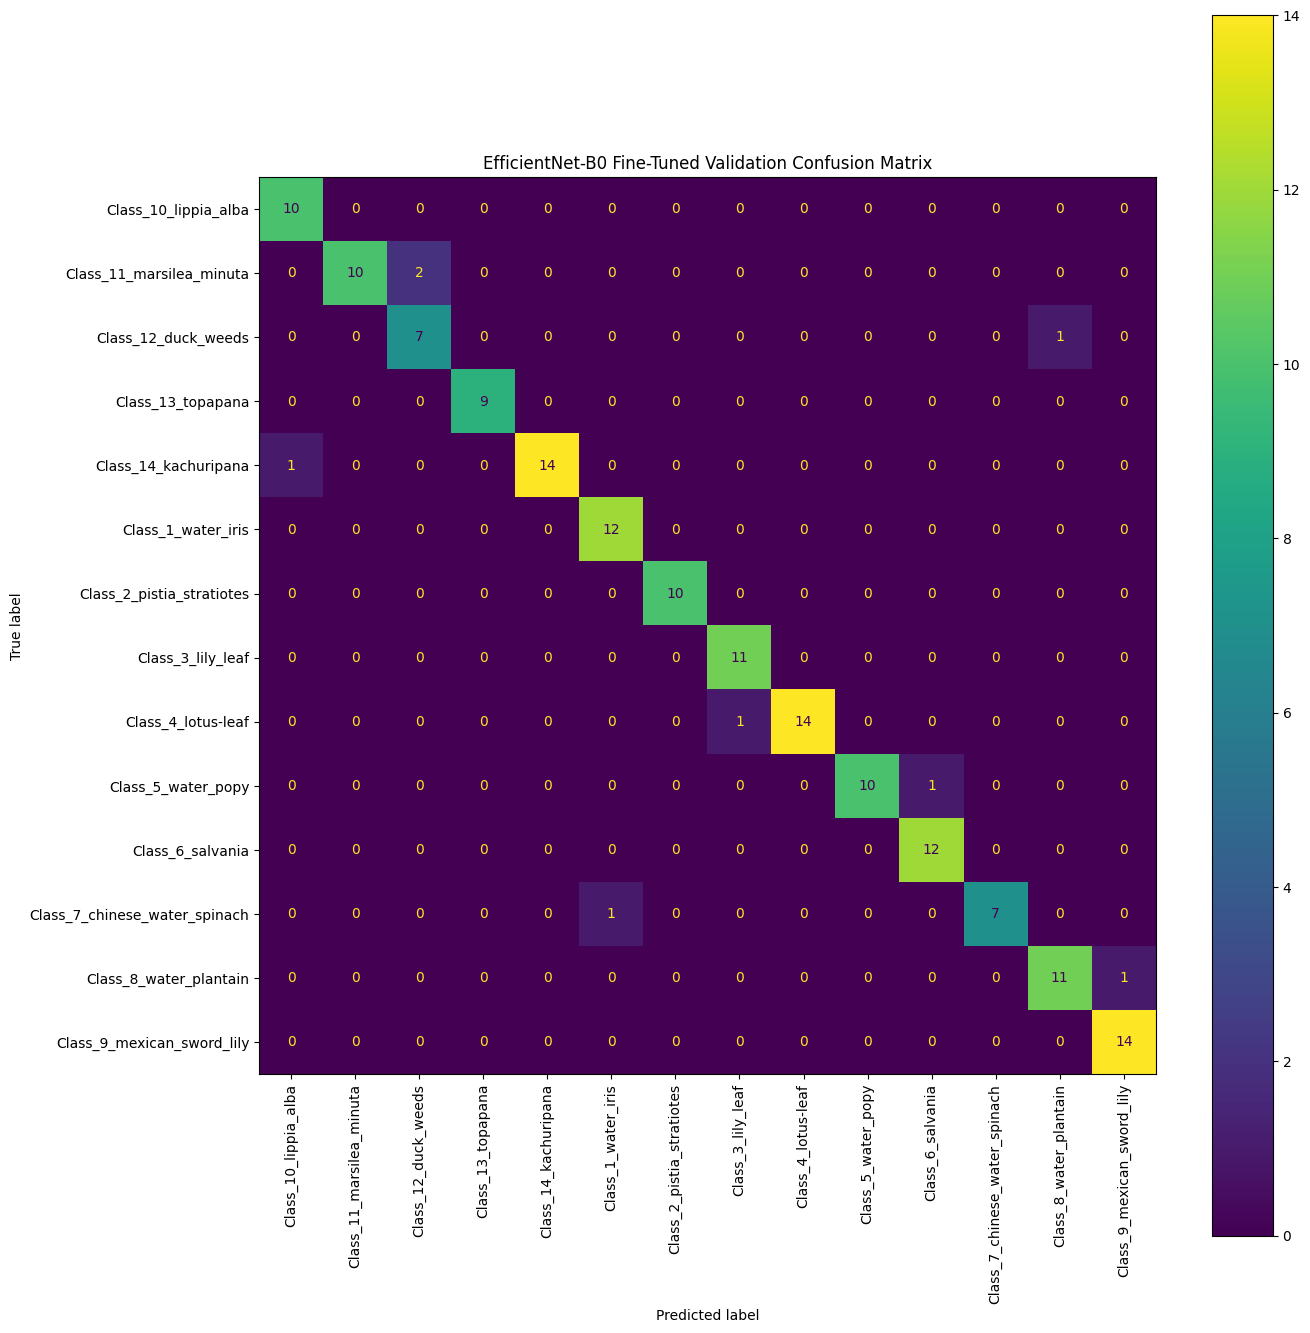

In [17]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    best_ft_val["targets"],
    best_ft_val["preds"]
)

fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=full_train_dataset.classes
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "EfficientNet-B0 Fine-Tuned Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [18]:
import os
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/CVPR/EfficientNet_B0_Results"

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_finetuned_50epochs_history.csv"
)

history_df = pd.read_csv(HISTORY_PATH)

print(history_df.tail())

    epoch  train_loss  train_accuracy  train_macro_f1  val_loss  val_accuracy  \
47     48    0.157740        0.981174        0.980780  0.297471      0.937107   
48     49    0.155260        0.981174        0.980685  0.305561      0.937107   
49     50    0.145962        0.986711        0.986833  0.282741      0.937107   
50     37    0.137467        0.982281        0.981750  0.301594      0.937107   
51     38    0.141600        0.985604        0.985445  0.290159      0.937107   

    val_precision  val_recall  val_macro_f1   backbone_lr  classifier_lr  
47       0.939859    0.935281      0.935628  1.953125e-08   2.441406e-08  
48       0.941607    0.937013      0.937520  1.953125e-08   2.441406e-08  
49       0.939859    0.935281      0.935628  1.953125e-08   2.441406e-08  
50       0.941102    0.935281      0.935837  1.953125e-08   1.220703e-08  
51       0.939859    0.935281      0.935628  1.953125e-08   1.220703e-08  


In [19]:
best_row = history_df.loc[
    history_df["val_macro_f1"].idxmax()
]

print("=" * 50)

print("Best Epoch:", int(best_row["epoch"]))

print(
    "Best Validation Accuracy:",
    f"{best_row['val_accuracy']*100:.2f}%"
)

print(
    "Best Validation Macro-F1:",
    f"{best_row['val_macro_f1']*100:.2f}%"
)

print(
    "Best Validation Loss:",
    f"{best_row['val_loss']:.4f}"
)

Best Epoch: 28
Best Validation Accuracy: 94.97%
Best Validation Macro-F1: 94.72%
Best Validation Loss: 0.3039


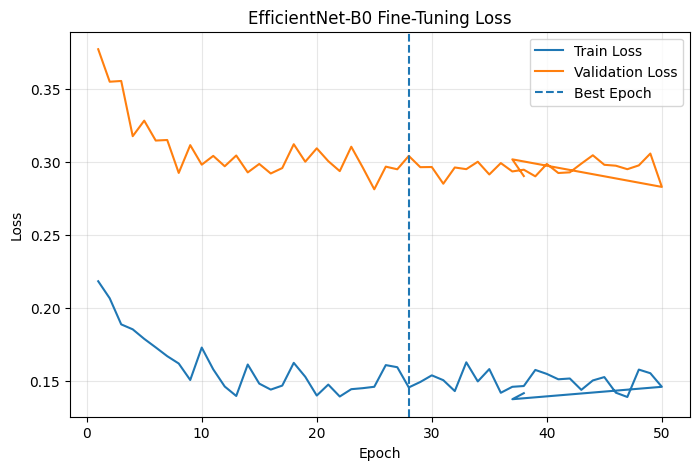

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=int(best_row["epoch"]),
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNet-B0 Fine-Tuning Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

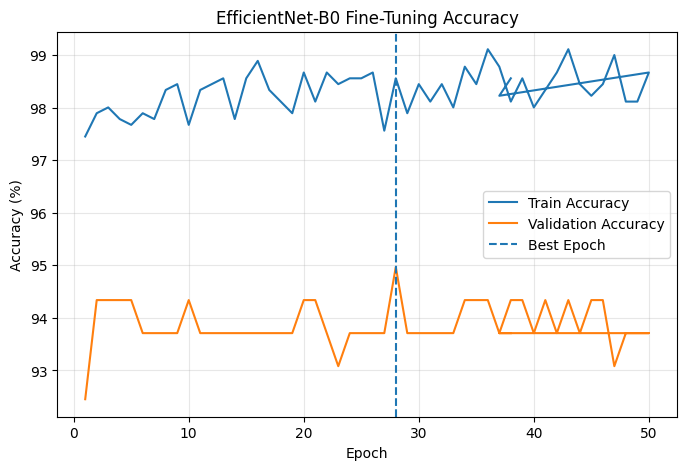

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"] * 100,
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"] * 100,
    label="Validation Accuracy"
)

plt.axvline(
    x=int(best_row["epoch"]),
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "EfficientNet-B0 Fine-Tuning Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

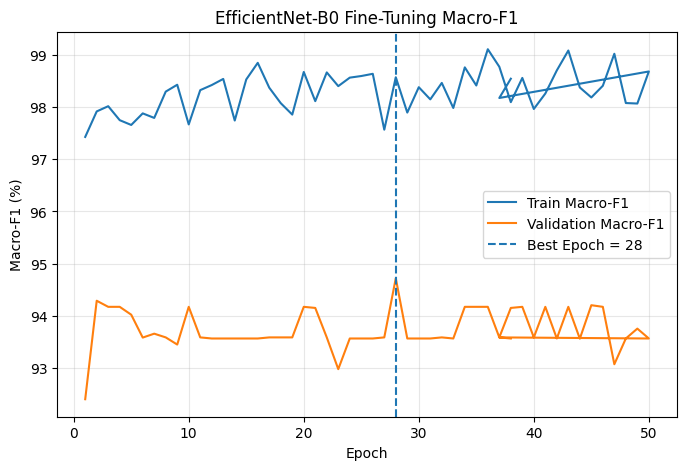

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"] * 100,
    label="Train Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"] * 100,
    label="Validation Macro-F1"
)

plt.axvline(
    x=int(best_row["epoch"]),
    linestyle="--",
    label=f"Best Epoch = {int(best_row['epoch'])}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1 (%)")

plt.title(
    "EfficientNet-B0 Fine-Tuning Macro-F1"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
frozen = {
    "Accuracy": 0.9434,
    "Precision": 0.9459,
    "Recall": 0.9418,
    "Macro-F1": 0.9417
}

finetuned = {
    "Accuracy": best_ft_val["accuracy"],
    "Precision": best_ft_val["precision"],
    "Recall": best_ft_val["recall"],
    "Macro-F1": best_ft_val["macro_f1"]
}

comparison = pd.DataFrame({
    "Metric": frozen.keys(),
    "Frozen": [v * 100 for v in frozen.values()],
    "Fine-Tuned": [v * 100 for v in finetuned.values()]
})

comparison["Improvement"] = (
    comparison["Fine-Tuned"]
    - comparison["Frozen"]
)

print(comparison.round(2))

      Metric  Frozen  Fine-Tuned  Improvement
0   Accuracy   94.34       94.97         0.63
1  Precision   94.59       95.00         0.41
2     Recall   94.18       94.83         0.65
3   Macro-F1   94.17       94.72         0.55


In [24]:
FINAL_RESULT_PATH = os.path.join(
    SAVE_DIR,
    "efficientnet_b0_final_summary.csv"
)

final_result = pd.DataFrame([{
    "Model": "EfficientNet-B0",
    "Training": "Fine-Tuned",
    "Best_Epoch": best_checkpoint["epoch"],
    "Validation_Accuracy": best_ft_val["accuracy"],
    "Validation_Precision": best_ft_val["precision"],
    "Validation_Recall": best_ft_val["recall"],
    "Validation_Macro_F1": best_ft_val["macro_f1"],
    "Validation_Loss": best_ft_val["loss"]
}])

final_result.to_csv(
    FINAL_RESULT_PATH,
    index=False
)

print("Final result saved ✅")
print(FINAL_RESULT_PATH)

Final result saved ✅
/content/drive/MyDrive/CVPR/EfficientNet_B0_Results/efficientnet_b0_final_summary.csv
